# Compare FAO56 to Measured Soil Heat Flux

## Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os
import sys
sys.path.append(os.path.abspath('../src'))

from soil_heat import soil_heat_flux_hourly_auto
import soil_heat

In [2]:
W_TO_MJ_HR = 0.0036  # W/m² to MJ/m²/hr


## Site configurations

In [3]:
# Site configurations
site_configs = {
    'Green River': {
        'path': 'C:/Users/paulinkenbrandt/Documents/ET/Green_River/US-UTG_flux_qaqc.csv',
        'rn_col': 'NETRAD_1_1_2_FINAL',
        'g_measured_col': 'G_1_1_1_FINAL',
        'dt_col': 'DATETIME_END',
        'fill_val': None,
    },
    'Myton': {
        'path': 'C:/Users/paulinkenbrandt/Documents/ET/Myton/US-UTV_flux_qaqc.csv',
        'rn_col': 'NETRAD_1_1_2_FINAL',
        'g_measured_col': 'G_1_1_A_FINAL',
        'dt_col': 'DATETIME_END',
        'fill_val': None,
    },
    'Pelican Lake': {
        'path': 'C:/Users/paulinkenbrandt/Documents/ET/Pelican_Lake/US-UTL_flux_qaqc.csv',
        'rn_col': 'NETRAD_1_1_2_FINAL',
        'g_measured_col': 'G_1_1_A',
        'dt_col': 'DATETIME_END',
        'fill_val': None,
    },
    'Wellington': {
        'path': 'C:/Users/paulinkenbrandt/Documents/ET/Wellington/US-UTW_flux_qaqc.csv',
        'rn_col': 'NETRAD_1_1_1',
        'g_measured_col': 'G_1_1_1',
        'dt_col': 'DATETIME_END',
        'fill_val': None,
    },
}


<Axes: xlabel='Timestamp'>

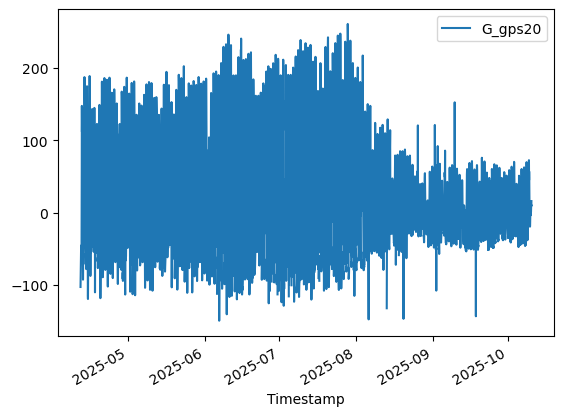

In [53]:
svn = pd.read_csv("C:/Users/paulinkenbrandt/Documents/ET/Green_River/northsoilvue_HH_202504112000_202510101900.csv",na_values=-9999)
svn['Timestamp'] = pd.to_datetime(svn['Timestamp'])
svn.set_index('Timestamp', inplace=True)
svn.columns

# SoilVUE depths
DEPTHS_CM = np.array([5, 10, 20, 30, 40], dtype=float)

suffixes = ["5_1_1", "5_2_1", "5_3_1", "5_4_1", "5_5_1"]
ts_cols = [f"TS_{s}" for s in suffixes]
swc_cols = [f"SWC_{s}" for s in suffixes]
ts = svn[ts_cols].copy()
ts.columns = DEPTHS_CM
swc = svn[swc_cols].copy()

swc.columns = DEPTHS_CM
swc = swc / 100.0  # percent → fractional

# --- Run all methods ---
G_gps20 = soil_heat.gradient_plus_storage(ts, swc, ref_depth_idx=2, lam_model="johansen")
G_gps20 = G_gps20.to_frame(name='G_gps20')
G_gps20['G_gps20'] = np.where(G_gps20['G_gps20'] < -150, np.nan, G_gps20['G_gps20'])  # Replace zeros with NaN for better plotting
G_gps20['G_gps20'] = G_gps20['G_gps20'].shift(-6)
G_gps20.plot()

# Run analysis for each site

In [54]:
results = {}
for site_name, cfg in site_configs.items():

    df = pd.read_csv(cfg['path'], parse_dates=[cfg['dt_col']])
    df = df.rename(columns={cfg['dt_col']: 'datetime'})
    df = df.set_index('datetime')
    if site_name == 'Green River':
        df['G_1_1_1_FINAL'] =  G_gps20['G_gps20']  # Use GPS20 estimates for Green River G
    if cfg['fill_val'] is not None:
        df = df.replace(cfg['fill_val'], np.nan)
    
    rn_col = cfg['rn_col']
    g_col = cfg['g_measured_col']
    
    mask = df[rn_col].notna() & df[g_col].notna()
    df_valid = df[mask].copy()
    
    # Convert Rn to MJ/m²/hr, estimate G, convert back
    rn_mj_hr = df_valid[rn_col].values * W_TO_MJ_HR
    g_est_mj_hr = soil_heat_flux_hourly_auto(rn_mj_hr, day_coeff=0.15)
    g_est_wm2 = g_est_mj_hr / W_TO_MJ_HR
    g_meas = df_valid[g_col].values
    
    # Statistics
    diff = g_est_wm2 - g_meas
    rmse = np.sqrt(np.nanmean(diff**2))
    mae = np.nanmean(np.abs(diff))
    bias = np.nanmean(diff)
    r = np.corrcoef(g_est_wm2, g_meas)[0, 1]
    
    results[site_name] = {
        'index': df_valid.index,
        'g_est': g_est_wm2,
        'g_meas': g_meas,
        'rn': df_valid[rn_col].values,
        'rmse': rmse, 'mae': mae, 'bias': bias, 'r': r,
        'n': len(df_valid),
        'date_range': f"{df_valid.index.min().strftime('%Y-%m-%d')} to {df_valid.index.max().strftime('%Y-%m-%d')}",
    }

# ---- FIGURE 1: Time series comparison (4 subplots) ----

Saved timeseries plot.


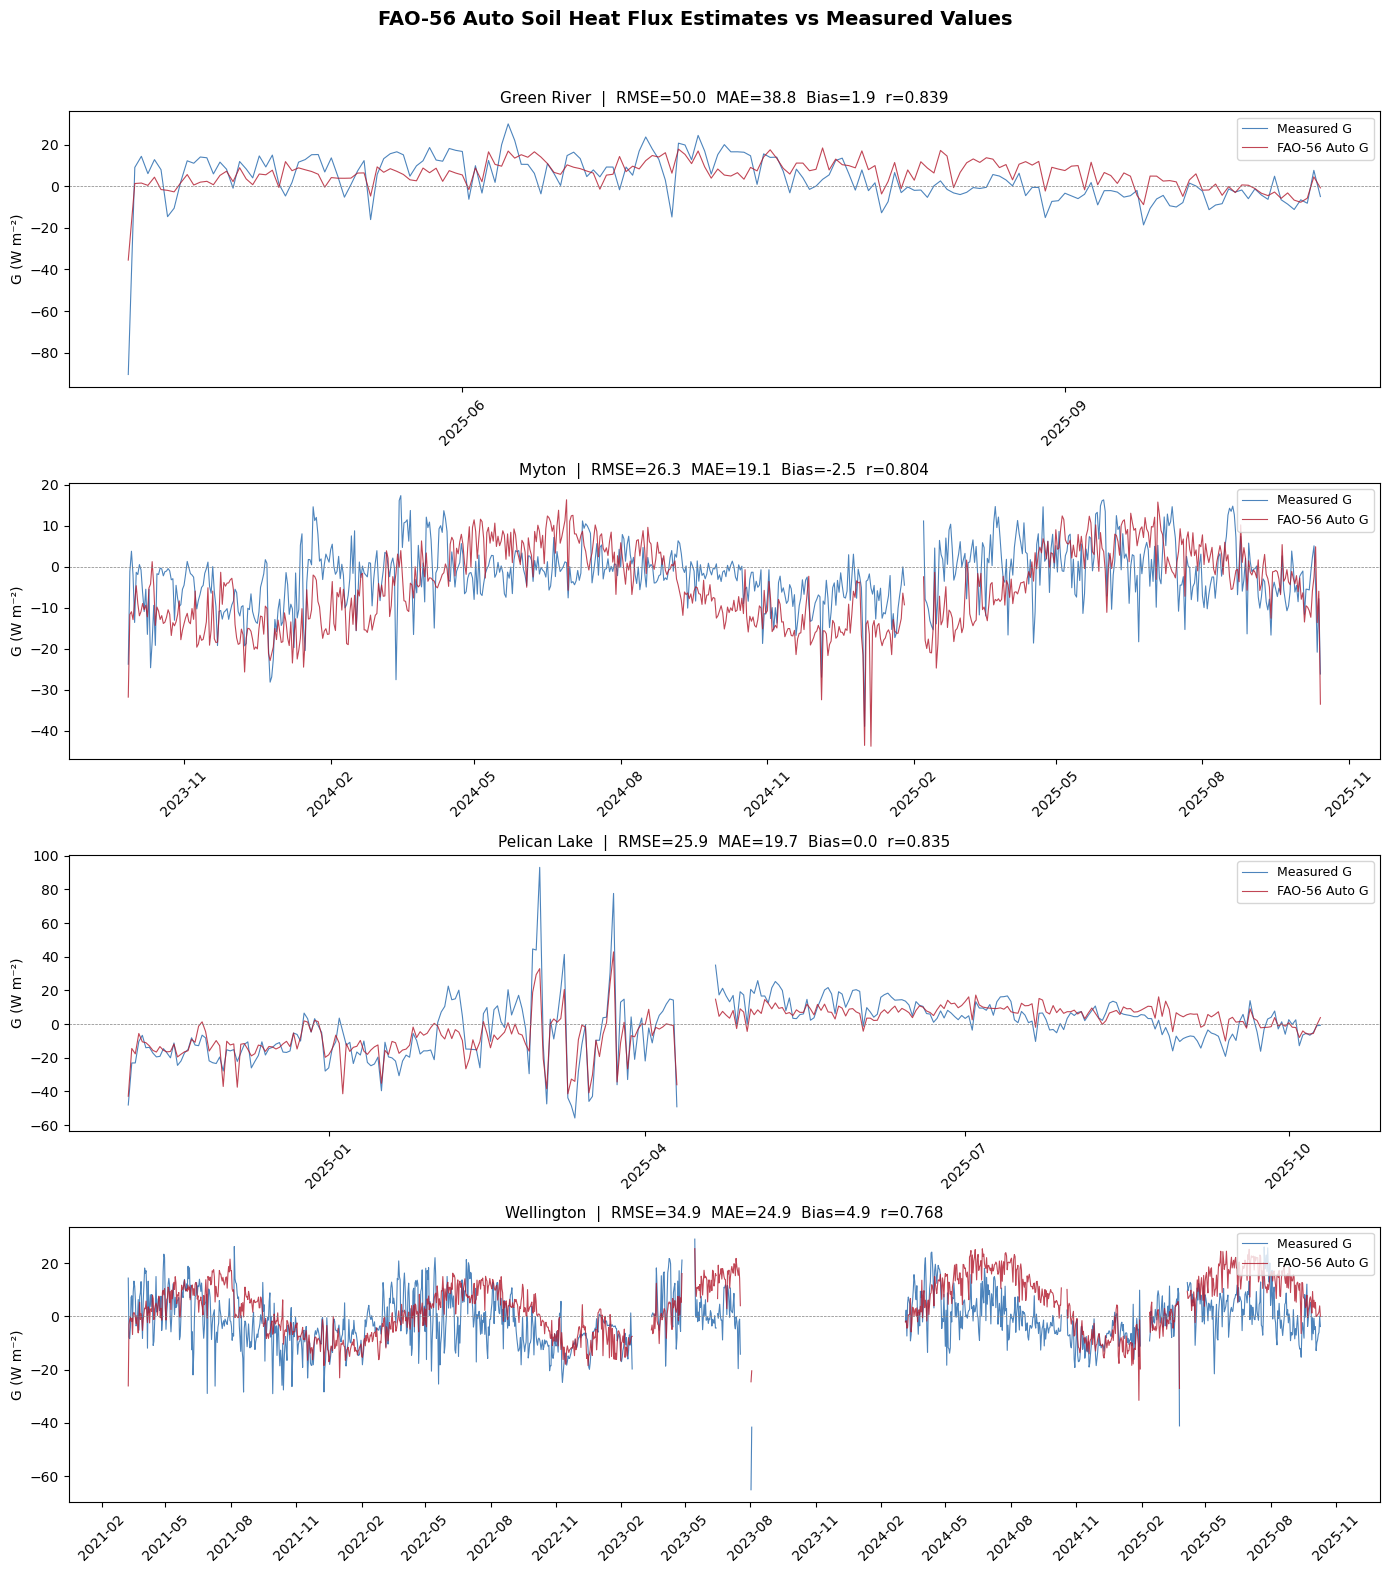

In [55]:
# ---- FIGURE 1: Time series comparison (4 subplots) ----
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
fig.suptitle('FAO-56 Auto Soil Heat Flux Estimates vs Measured Values', fontsize=14, fontweight='bold', y=0.98)

for ax, (site_name, r) in zip(axes, results.items()):
    # Downsample for plotting if too many points
    idx = r['index']
    g_m = r['g_meas']
    g_e = r['g_est']
    
    # Daily averages for cleaner time series
    df_plot = pd.DataFrame({'measured': g_m, 'estimated': g_e}, index=idx)
    daily = df_plot.resample('D').mean()
    
    ax.plot(daily.index, daily['measured'], color='#2166ac', linewidth=0.8, alpha=0.8, label='Measured G')
    ax.plot(daily.index, daily['estimated'], color='#b2182b', linewidth=0.8, alpha=0.8, label='FAO-56 Auto G')
    ax.set_ylabel('G (W m⁻²)')
    ax.set_title(f'{site_name}  |  RMSE={r["rmse"]:.1f}  MAE={r["mae"]:.1f}  Bias={r["bias"]:.1f}  r={r["r"]:.3f}', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('C:/Users/paulinkenbrandt/Documents/ET/fao56_timeseries_comparison.png', dpi=150, bbox_inches='tight')

print("Saved timeseries plot.")

# ---- FIGURE 2: Scatter plots (2x2) ----

Saved scatter plot.


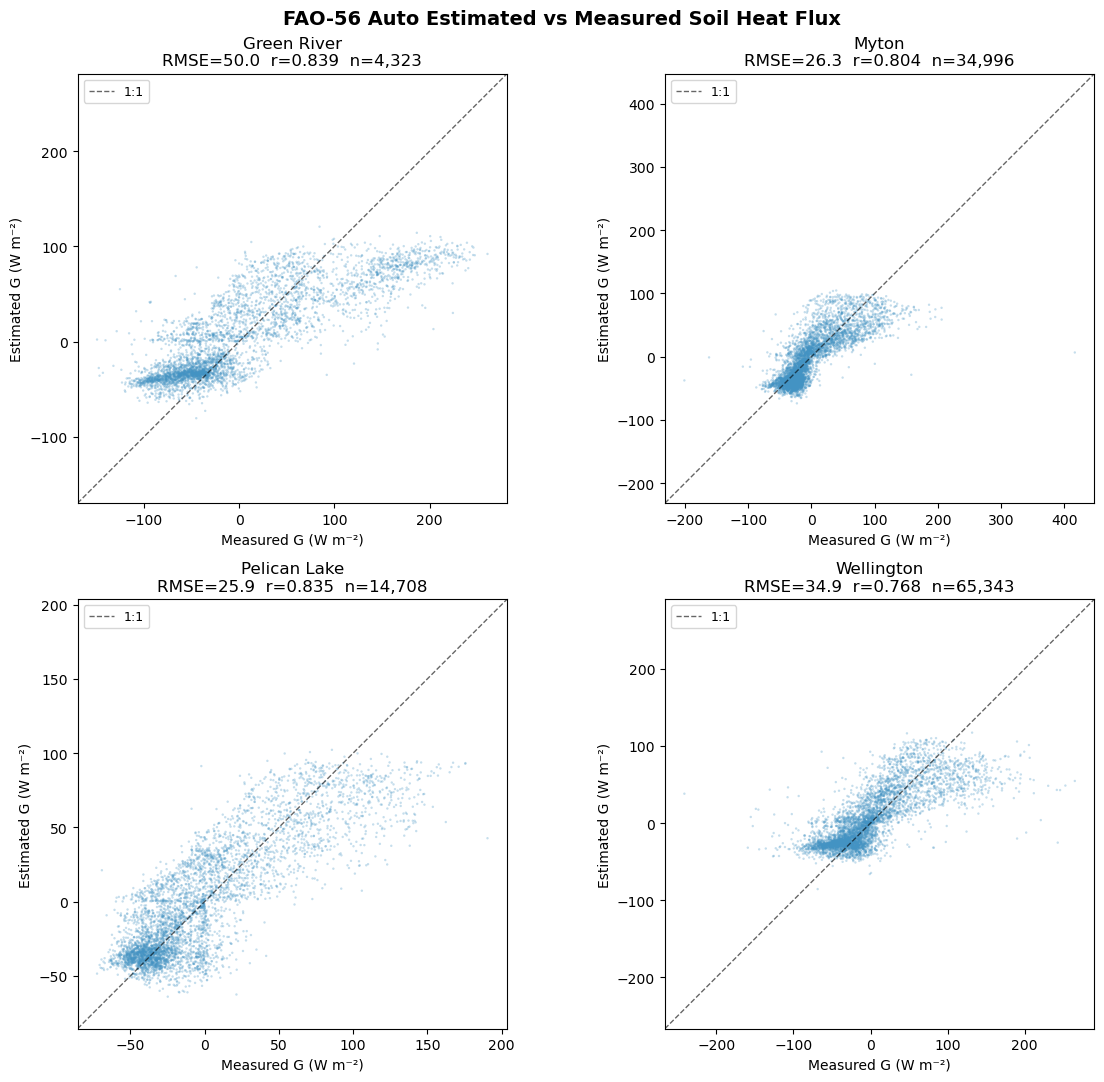

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle('FAO-56 Auto Estimated vs Measured Soil Heat Flux', fontsize=14, fontweight='bold')

for ax, (site_name, r) in zip(axes.flat, results.items()):
    g_m = r['g_meas']
    g_e = r['g_est']
    
    # Subsample for scatter if needed
    if len(g_m) > 5000:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(g_m), 5000, replace=False)
        g_m_plot, g_e_plot = g_m[idx], g_e[idx]
    else:
        g_m_plot, g_e_plot = g_m, g_e
    
    ax.scatter(g_m_plot, g_e_plot, s=3, alpha=0.3, color='#4393c3', edgecolors='none')
    
    # 1:1 line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    
    ax.set_xlabel('Measured G (W m⁻²)')
    ax.set_ylabel('Estimated G (W m⁻²)')
    ax.set_title(f'{site_name}\nRMSE={r["rmse"]:.1f}  r={r["r"]:.3f}  n={r["n"]:,}')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('C:/Users/paulinkenbrandt/Documents/ET/fao56_scatter_comparison.png', dpi=150, bbox_inches='tight')
print("Saved scatter plot.")

# ---- FIGURE 3: Diurnal cycle comparison ----

Saved diurnal plot.


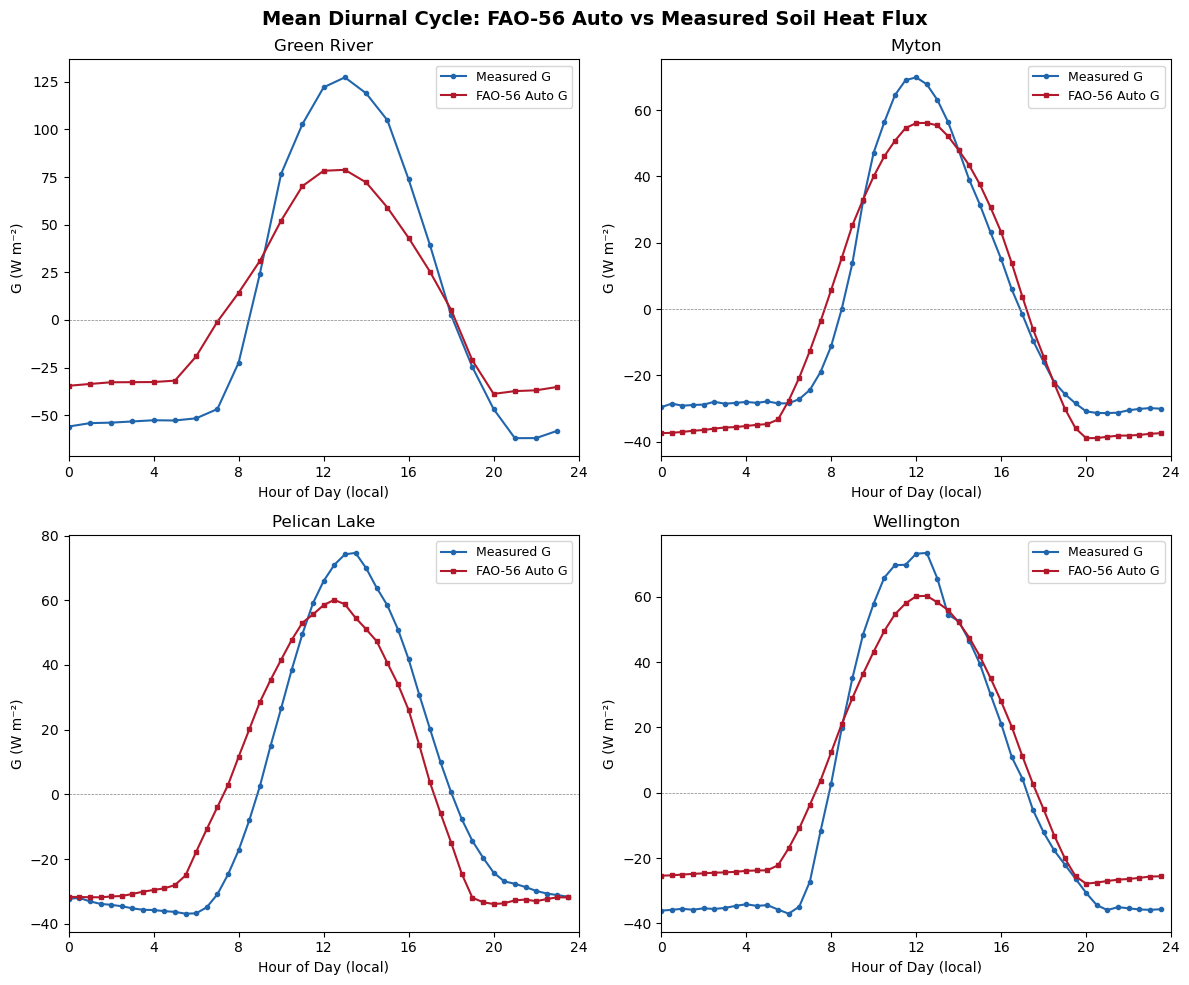

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Mean Diurnal Cycle: FAO-56 Auto vs Measured Soil Heat Flux', fontsize=14, fontweight='bold')

for ax, (site_name, r) in zip(axes.flat, results.items()):
    df_diurnal = pd.DataFrame({'measured': r['g_meas'], 'estimated': r['g_est']}, index=r['index'])
    df_diurnal['hour'] = df_diurnal.index.hour + df_diurnal.index.minute / 60.0
    hourly_mean = df_diurnal.groupby('hour').mean()
    
    ax.plot(hourly_mean.index, hourly_mean['measured'], 'o-', color='#2166ac', markersize=3, linewidth=1.5, label='Measured G')
    ax.plot(hourly_mean.index, hourly_mean['estimated'], 's-', color='#b2182b', markersize=3, linewidth=1.5, label='FAO-56 Auto G')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Hour of Day (local)')
    ax.set_ylabel('G (W m⁻²)')
    ax.set_title(site_name)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))

plt.tight_layout()
plt.savefig('C:/Users/paulinkenbrandt/Documents/ET/fao56_diurnal_comparison.png', dpi=150, bbox_inches='tight')
print("Saved diurnal plot.")

In [58]:






# Print summary table
print("\n" + "="*80)
print("SUMMARY: FAO-56 Hourly Auto Soil Heat Flux Comparison")
print("="*80)
print(f"{'Site':<16} {'n':>8} {'RMSE':>8} {'MAE':>8} {'Bias':>8} {'r':>8}  Date Range")
print("-"*80)
for site_name, r in results.items():
    print(f"{site_name:<16} {r['n']:>8,} {r['rmse']:>8.1f} {r['mae']:>8.1f} {r['bias']:>8.1f} {r['r']:>8.3f}  {r['date_range']}")
print("-"*80)
print("Units: W/m² for RMSE, MAE, and Bias")
print("Method: soil_heat.soil_heat_flux_hourly_auto(Rn) with day_coeff=0.15, night_coeff=0.5")


SUMMARY: FAO-56 Hourly Auto Soil Heat Flux Comparison
Site                    n     RMSE      MAE     Bias        r  Date Range
--------------------------------------------------------------------------------
Green River         4,323     50.0     38.8      1.9    0.839  2025-04-11 to 2025-10-10
Myton              34,996     26.3     19.1     -2.5    0.804  2023-09-27 to 2025-10-14
Pelican Lake       14,708     25.9     19.7      0.0    0.835  2024-11-05 to 2025-10-10
Wellington         65,343     34.9     24.9      4.9    0.768  2021-03-10 to 2025-10-10
--------------------------------------------------------------------------------
Units: W/m² for RMSE, MAE, and Bias
Method: soil_heat.soil_heat_flux_hourly_auto(Rn) with day_coeff=0.15, night_coeff=0.5
